# Model Tester

In [50]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import os
import sys
import math
import logging
import healpy as hp
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

from tensorflow.keras.layers import (  # type: ignore
    Dense,
    Dropout,
    Flatten,
    LeakyReLU,
    Permute,
)
from tensorflow.keras.callbacks import (  # type: ignore
    EarlyStopping,
    TerminateOnNaN,
    TensorBoard,
    ModelCheckpoint,
)
from tensorflow.keras.optimizers import Adam, AdamW  # type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay  # type: ignore
from tensorflow.keras.metrics import RootMeanSquaredError  # type: ignore

from mlpng import Core
from mlpng.utils import (
    setup_logging,
    get_fisher,
    plot_predictions,
    plot_histogram,
    print_errors,
    plot_metrics,
    try_init_wandb,
)
from mlpng.utils.dataloaders import HDF5Dataset

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)


os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
# os.environ["XLA_FLAGS"] = (
#     "--xla_gpu_cuda_data_dir=/hpc/mp/apps/nvidia/hpc_sdk/23.7/Linux_x86_64/23.7/cuda"
# )

keras = tf.keras

In [52]:
print("Conda environment:", os.environ["CONDA_DEFAULT_ENV"])
print("Python executable:", sys.executable)

Conda environment: deepsphere
Python executable: /work/users/stevensonb/.conda/envs/deepsphere/bin/python


In [53]:
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")
# print(f"keras version: {keras.__version__}")

TensorFlow version: 2.15.1
CUDA version: 12.2
cuDNN version: 8


In [54]:
logger = setup_logging(__name__, level=logging.DEBUG)

In [55]:
MAX_EPOCHS = 100
BATCH_SIZE = 32


def rotate_ds(inputs, y):
    @tf.py_function(Tout=tf.float32)  # type: ignore
    def rotate_map(inputs):
        lat_angle = tf.random.uniform([1], -90.0, 90.0)  # type: ignore
        lon_angle = tf.random.uniform([1], -180.0, 180.0)  # type: ignore
        rotator = hp.Rotator(rot=[lat_angle, lon_angle], deg=True, inv=True)
        x = hp.reorder(inputs, n2r=True)

        # I have had issues in the past with the pixel weights not being downloaded due to server errors
        # disable here if you get an error with the file not being found on astropy's servers
        x = rotator.rotate_map_alms(x, use_pixel_weights=True)
        return hp.reorder(x, r2n=True)

    x = tf.map_fn(rotate_map, inputs)
    x.set_shape(inputs.shape)  # type: ignore
    return x, y


def to_tf(ds, core, batch_size=BATCH_SIZE, prerotate=True, reshuffle=True):
    npix = hp.nside2npix(core.nside)
    dataset = tf.data.Dataset.from_generator(
        lambda: ds,
        output_signature=(
            tf.TensorSpec(shape=(core.ndups, core.npols, npix), dtype=tf.float32),  # type: ignore
            tf.TensorSpec(shape=(core.ndups,), dtype=tf.float32),  # type: ignore
        ),
    )

    # takes us from 1 element of (ndups, npols, npix) to ndup elements of (npols, npix)
    dataset = dataset.apply(tf.data.Dataset.unbatch)

    if prerotate:
        # apply rotations, do this before cache because its slow
        dataset = dataset.map(rotate_ds, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.cache()

    if not prerotate:
        dataset = dataset.map(rotate_ds, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.shuffle(buffer_size=1024, reshuffle_each_iteration=reshuffle)
    dataset = dataset.batch(
        batch_size,
        drop_remainder=True,
        num_parallel_calls=tf.data.AUTOTUNE,
        # deterministic=False,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


def get_model(input_shape):
    nside = hp.npix2nside(input_shape[2])
    indices = np.arange(input_shape[2])
    layers = []

    layers.append(Permute((2, 1)))

    n_layers = math.floor(math.log(nside, 2))
    for i in range(n_layers):
        fout = 2 ** (4 + i)
        layers.append(
            HealpyChebyshev(
                K=2,
                Fout=fout,
                use_bias=True,
                use_bn=True,
                activation=LeakyReLU(0.3),
            )
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(1))

    model = HealpyGCNN(
        nside,
        indices=indices,
        layers=layers,
        max_batch_size=BATCH_SIZE,
        initial_Fin=input_shape[1],
        n_neighbors=8,
    )

    model.build(input_shape)
    return model

In [56]:
core = Core(
    [
        "settings/n32.json",
        "--nsims",
        "1000",
        # "--fnl_range",
        # "-100",
        # "100",
        "--pols",
        "T",
    ]
)

20-Jan-25 14:40:03 - mlpng.core - INFO - Parsing CLI args: ['settings/n32.json', '--nsims', '1000', '--pols', 'T']
20-Jan-25 14:40:03 - mlpng.core - INFO - Loading settings from file 'settings/n32.json'
20-Jan-25 14:40:03 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1000 due to CLI
20-Jan-25 14:40:03 - mlpng.core - DEBUG - Forcing setting 'pols' to ['T'] due to CLI
20-Jan-25 14:40:03 - mlpng.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4, 'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
20-Jan-25 14:40:03 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
20-Jan-25 14:40:03 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.9649
20-Jan-25 14:40:03 - mlpng.core - INFO - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.9649,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch

In [57]:
fisher = get_fisher(core.file, "fisher_iso")
npix = hp.nside2npix(core.nside)

f = 1
ds = HDF5Dataset(core.file, x_name="map", y_name="fnl", verbose=True)
train_ds, val_ds, test_ds = ds.split(0.8 / f, 0.1 / f, 0.1 / f)
train_tf = to_tf(train_ds, core)
val_tf = to_tf(val_ds, core)
test_tf = to_tf(test_ds, core, reshuffle=False)

decay_steps = len(train_ds) // BATCH_SIZE  # once per epoch

with tf.distribute.MirroredStrategy().scope():
    learning_rate = ExponentialDecay(1e-2, decay_steps, 0.95, staircase=True)

    model = get_model((BATCH_SIZE, core.npols, npix))
    # model = get_model((None, npix, core.npols))
    model.compile(
        optimizer=AdamW(learning_rate, weight_decay=0.1),  # type: ignore
        loss="mse",
        metrics=[RootMeanSquaredError()],  # type: ignore
    )

model.summary()

20-Jan-25 14:40:03 - mlpng.utils.utils - INFO - Loaded fisher: 0.00013775967818219215, with error: 85.19987159061358
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - DEBUG - Loaded HDF5 dataset: 'data/data/l95_n32_T_1000x25_f100.hdf5'
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - DEBUG - Found keys: <KeysViewHDF5 ['alm', 'alm_l', 'alm_lensed', 'alm_nl', 'fisher_iso', 'fisher_iso_lensed', 'fnl', 'fnl_norm', 'map', 'map_lensed', 'phi_map']>
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - DEBUG - Data shape: ((1000, 25, 1, 12288), (1000, 25, 1, 1))
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - INFO - Splitting data into train: 800, val: 100, test: 100
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - DEBUG - Loaded HDF5 dataset: 'data/data/l95_n32_T_1000x25_f100.hdf5'
20-Jan-25 14:40:03 - mlpng.utils.dataloaders - DEBUG - Found keys: <KeysViewHDF5 ['alm', 'alm_l', 'alm_lensed', 'alm_nl', 'fisher_iso', 'fisher_iso_lensed', 'fnl', 'fnl_norm', 'map', 'map_lensed', 'phi_map']>
20-Jan-25 14:40:03 

In [58]:
tf_dir = f"{core.dirs['tb']}/{core.name}-jorik"
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    TensorBoard(log_dir=tf_dir),
    ModelCheckpoint(tf_dir, monitor="val_loss", save_best_only=True),
]
# try_init_wandb(notes="model testing", tags=["SCNUNet"], append_to=callbacks)

history = model.fit(
    train_tf,
    epochs=MAX_EPOCHS,
    validation_data=val_tf,
    callbacks=callbacks,
    verbose=2,
)
# model.save(f"{core.dirs['model']}/{core.name}-{core.slurm.job}-jorik.keras")

###########################################################

logger.debug("Getting final plots")
truth = np.concatenate([y for _, y in test_tf])  # type: ignore
preds = model.predict(test_tf, verbose=0)
# using evaluate to get the rmse since manually calculating it was giving a different value
rmse = model.evaluate(test_tf, verbose=0)[1]

print_errors(truth, preds, fisher)

Epoch 1/100
INFO:tensorflow:Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
20-Jan-25 14:45:01 - tensorflow - INFO - Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
625/625 - 297s - loss: 3306.1089 - root_mean_squared_error: 57.4988 - val_loss: 195743.6719 - val_root_mean_squared_error: 442.4293 - 297s/epoch - 475ms/step
Epoch 2/100
INFO:tensorflow:Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
20-Jan-25 14:45:09 - tensorflow - INFO - Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
625/625 - 7s - loss: 2489.5564 - root_mean_squared_error: 49.8955 - val_loss: 4433.8135 - val_root_mean_squared_error: 66.5869 - 7s/epoch - 12ms/step
Epoch 3/100
INFO:tensorflow:Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
20-Jan-25 14:45:15 - tensorflow - INFO - Assets written to: data/tensorboard/l95_n32_T_1000x25_f100-jorik/assets
625/625 - 7s - loss: 2360.8176 - root_mean_squared_er

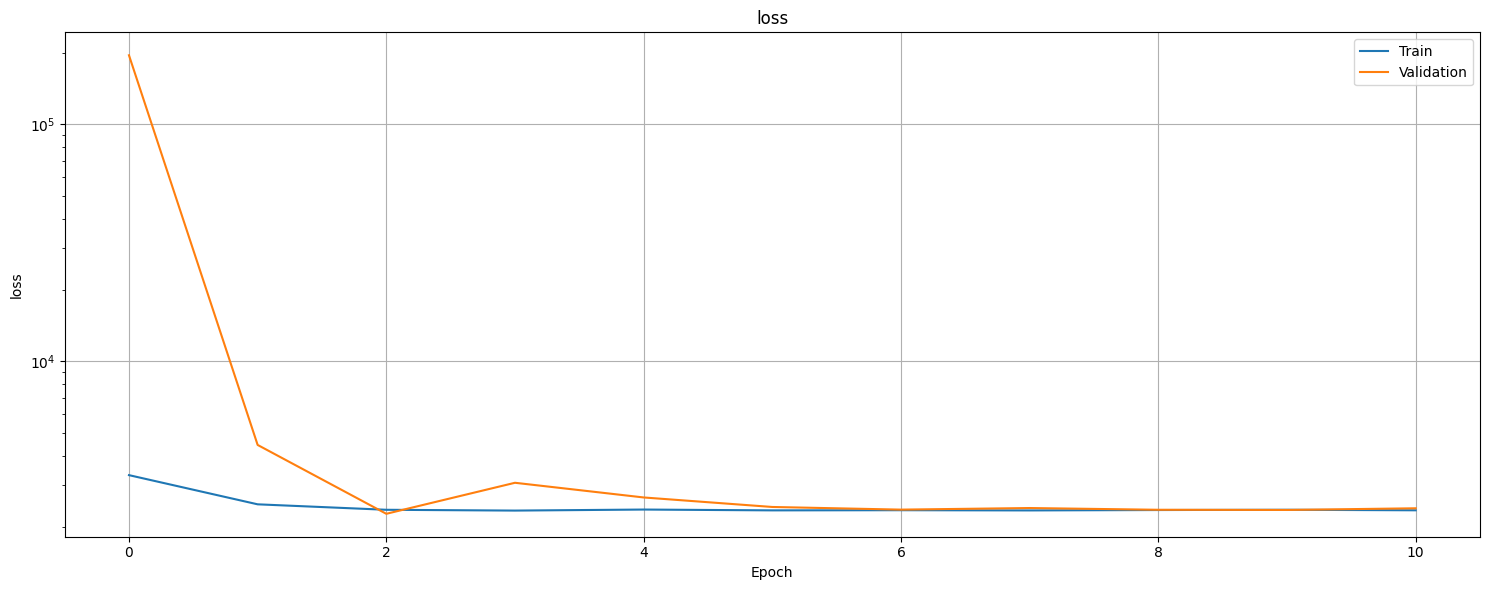

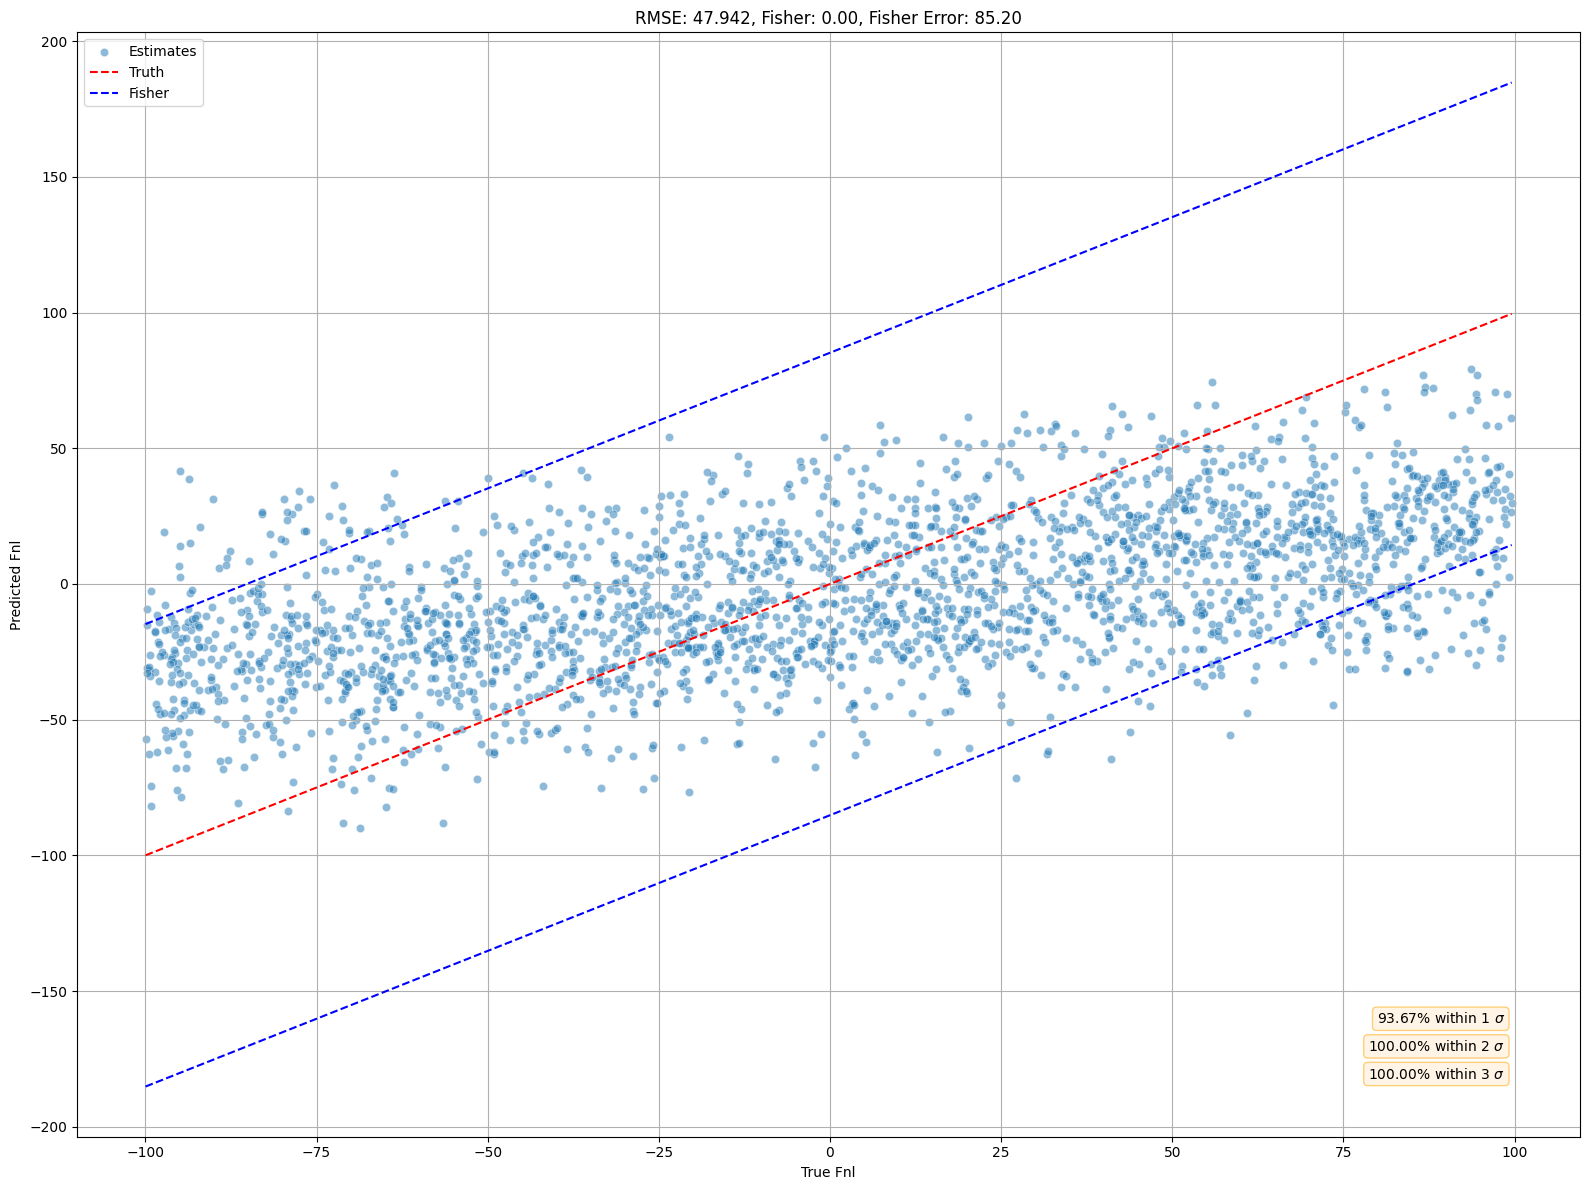

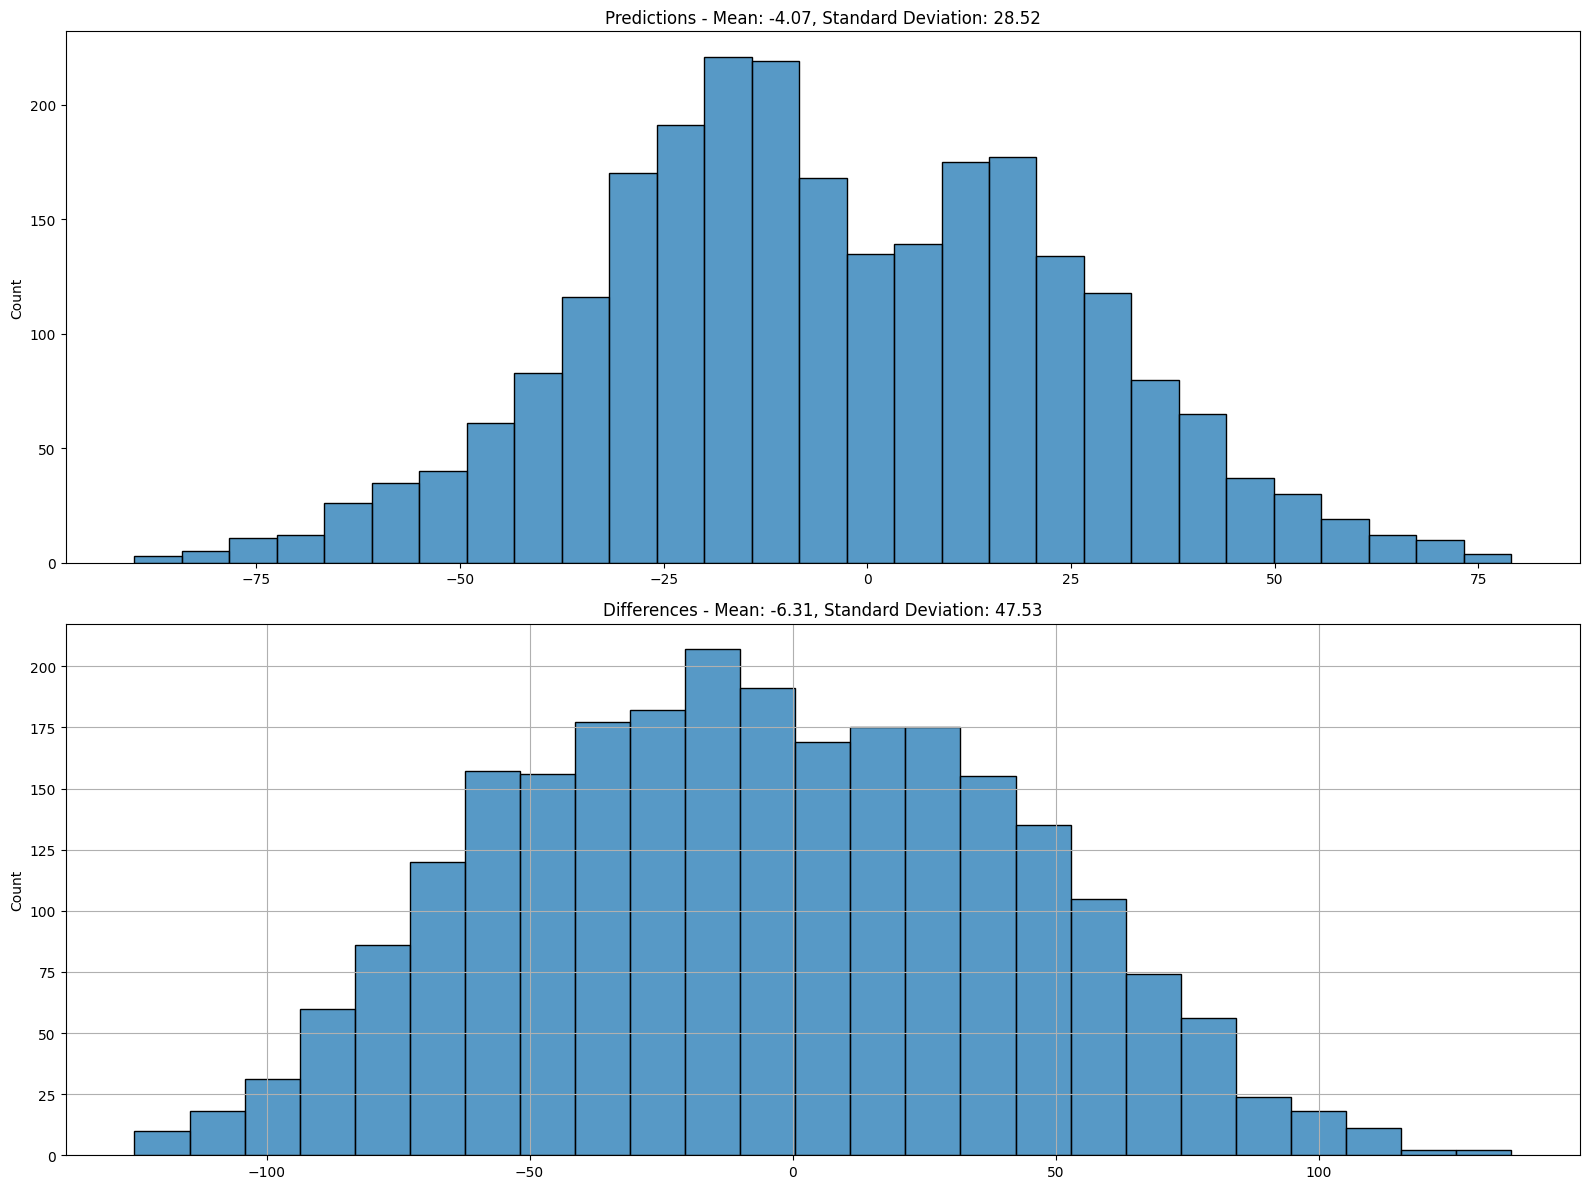

In [59]:
plot_metrics(history, metrics=["loss"], show=True)
plot_predictions(truth, preds, fisher=fisher, title=f"RMSE: {rmse:.3f}", show=True)
plot_histogram(truth, preds, show=True)